In [1]:
import sys
sys.path.append("../../../")

import numpy as np
import matplotlib.pyplot as plt

from LRM.plotting import set_plot_style


set_plot_style()

In [2]:
labels = [["CPB1", "SCGB2A2", "MUCL1", "SCGB1D2", "CLEC3A"],["TFF1", "S100A7", "SERPINA6", "UGT2B11", "KCNJ3"]]
flat_labels = [lab for row in labels for lab in row]
label_to_idx = {lab: k for k, lab in enumerate(flat_labels)}


## Plotting main text

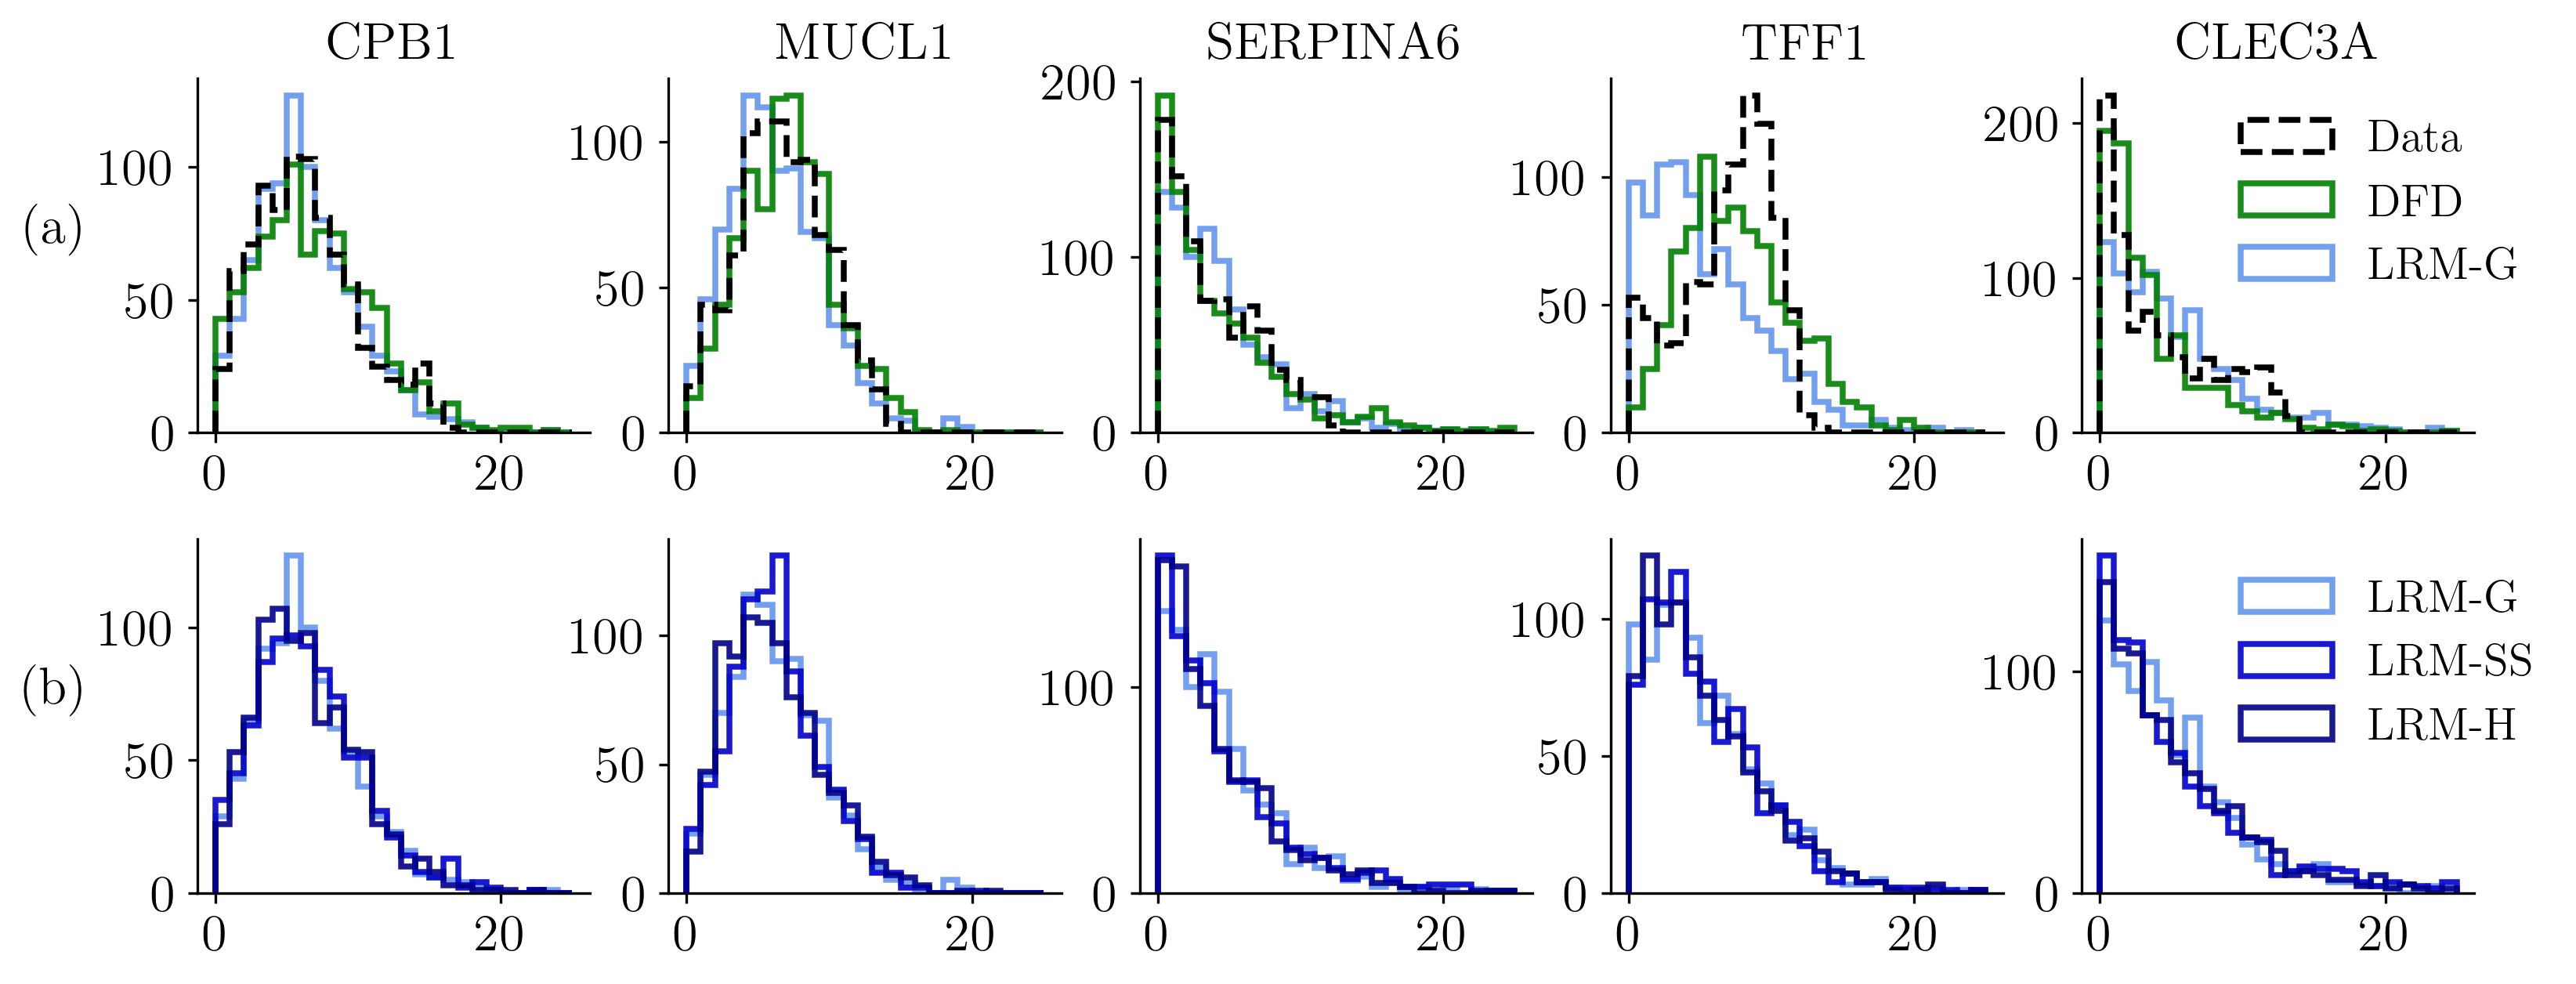

In [6]:
labels_main = ["CPB1", "MUCL1", "SERPINA6", "TFF1", "CLEC3A"]
selected_main_idx = [label_to_idx[lab] for lab in labels_main]

def plot(labels, select_idx, figsize=(12.5,4.5), save=False, filename=None):
    alpha=0.1
    tau0=0.1
    raw_data = np.load("../../../data/brca_10.npy").astype(np.int64)
    LRM_gaussian_prior = np.load(f"outputs/posterior_pred_samples_LRM_calibrated_alpha={alpha}.npz")["model_data"]
    LRM_spike_slab_prior = np.load(f"outputs/posterior_pred_samples_LRM_spike_slab_calibrated_alpha={alpha}.npz")["model_data"]
    LRM_horseshoe_prior = np.load(f"outputs/posterior_pred_samples_LRM_horseshoe_calibrated_alpha={alpha}_tau0={tau0}.npz")["model_data"]
    DFDBayes = np.load("../../../DiscreteFisherBayes/Graphical/Res/CMPGM_FDBayes_numdim=10_numchains=4_numsample=10000_numboot=100_numpred=100_numpredsample=500000_predictives.npy")
    count=0
    N_MAX=25
    lw=1.8
    fig, axs = plt.subplots(2, 5, figsize=figsize)

    for j, lab, count in zip(range(5), labels, select_idx):
        axs[0, j].hist(raw_data[:, count], histtype='step', bins=np.arange(N_MAX+1), label="Data",color='black', linestyle='--', linewidth=lw, zorder=3)
        axs[0, j].hist(DFDBayes[0, :, count], histtype='step', bins=np.arange(N_MAX+1), label="DFD", color='green', linestyle='-', linewidth=lw, alpha=0.9, zorder=2)
        axs[0, j].hist(LRM_gaussian_prior[:, count], histtype='step', bins=np.arange(N_MAX+1), label="LRM-G", color='cornflowerblue', linestyle='-', linewidth=lw, alpha=0.9, zorder=1)
        axs[0, j].set_title(lab, fontsize=16)

    for j, lab, count in zip(range(5), labels_main, selected_main_idx):
        axs[1, j].hist(LRM_gaussian_prior[:, count], histtype='step', bins=np.arange(N_MAX+1), label="LRM-G", color='cornflowerblue', linestyle='-', linewidth=lw, alpha=0.9, zorder=1)
        axs[1, j].hist(LRM_spike_slab_prior[:, count], histtype='step', bins=np.arange(N_MAX+1), label="LRM-SS", color='mediumblue', linestyle='-', linewidth=lw, alpha=0.9, zorder=1)
        axs[1, j].hist(LRM_horseshoe_prior[:, count], histtype='step', bins=np.arange(N_MAX+1), label="LRM-H", color='darkblue', linestyle='-', linewidth=lw, alpha=0.9, zorder=1)



    axs[0,-1].legend(frameon=False, fontsize=14, loc="upper left", bbox_to_anchor=(0.3, 1))
    axs[1,-1].legend(frameon=False, fontsize=14, bbox_to_anchor=(0.3, 1))

    axs[0, 0].set_ylabel("(a)", rotation=0, labelpad=13, fontdict={"fontsize": 16})
    axs[1, 0].set_ylabel("(b)", rotation=0, labelpad=13, fontdict={"fontsize": 16})


    for ax in axs.flat:
        ax.tick_params(axis='both', labelsize=16)


    fig.subplots_adjust(hspace=0.3)

    if save:
        plt.savefig(filename, format='pdf', bbox_inches='tight')

plot(labels_main, selected_main_idx, save=True, filename="./results/BRCA-study-all-main-text.pdf")

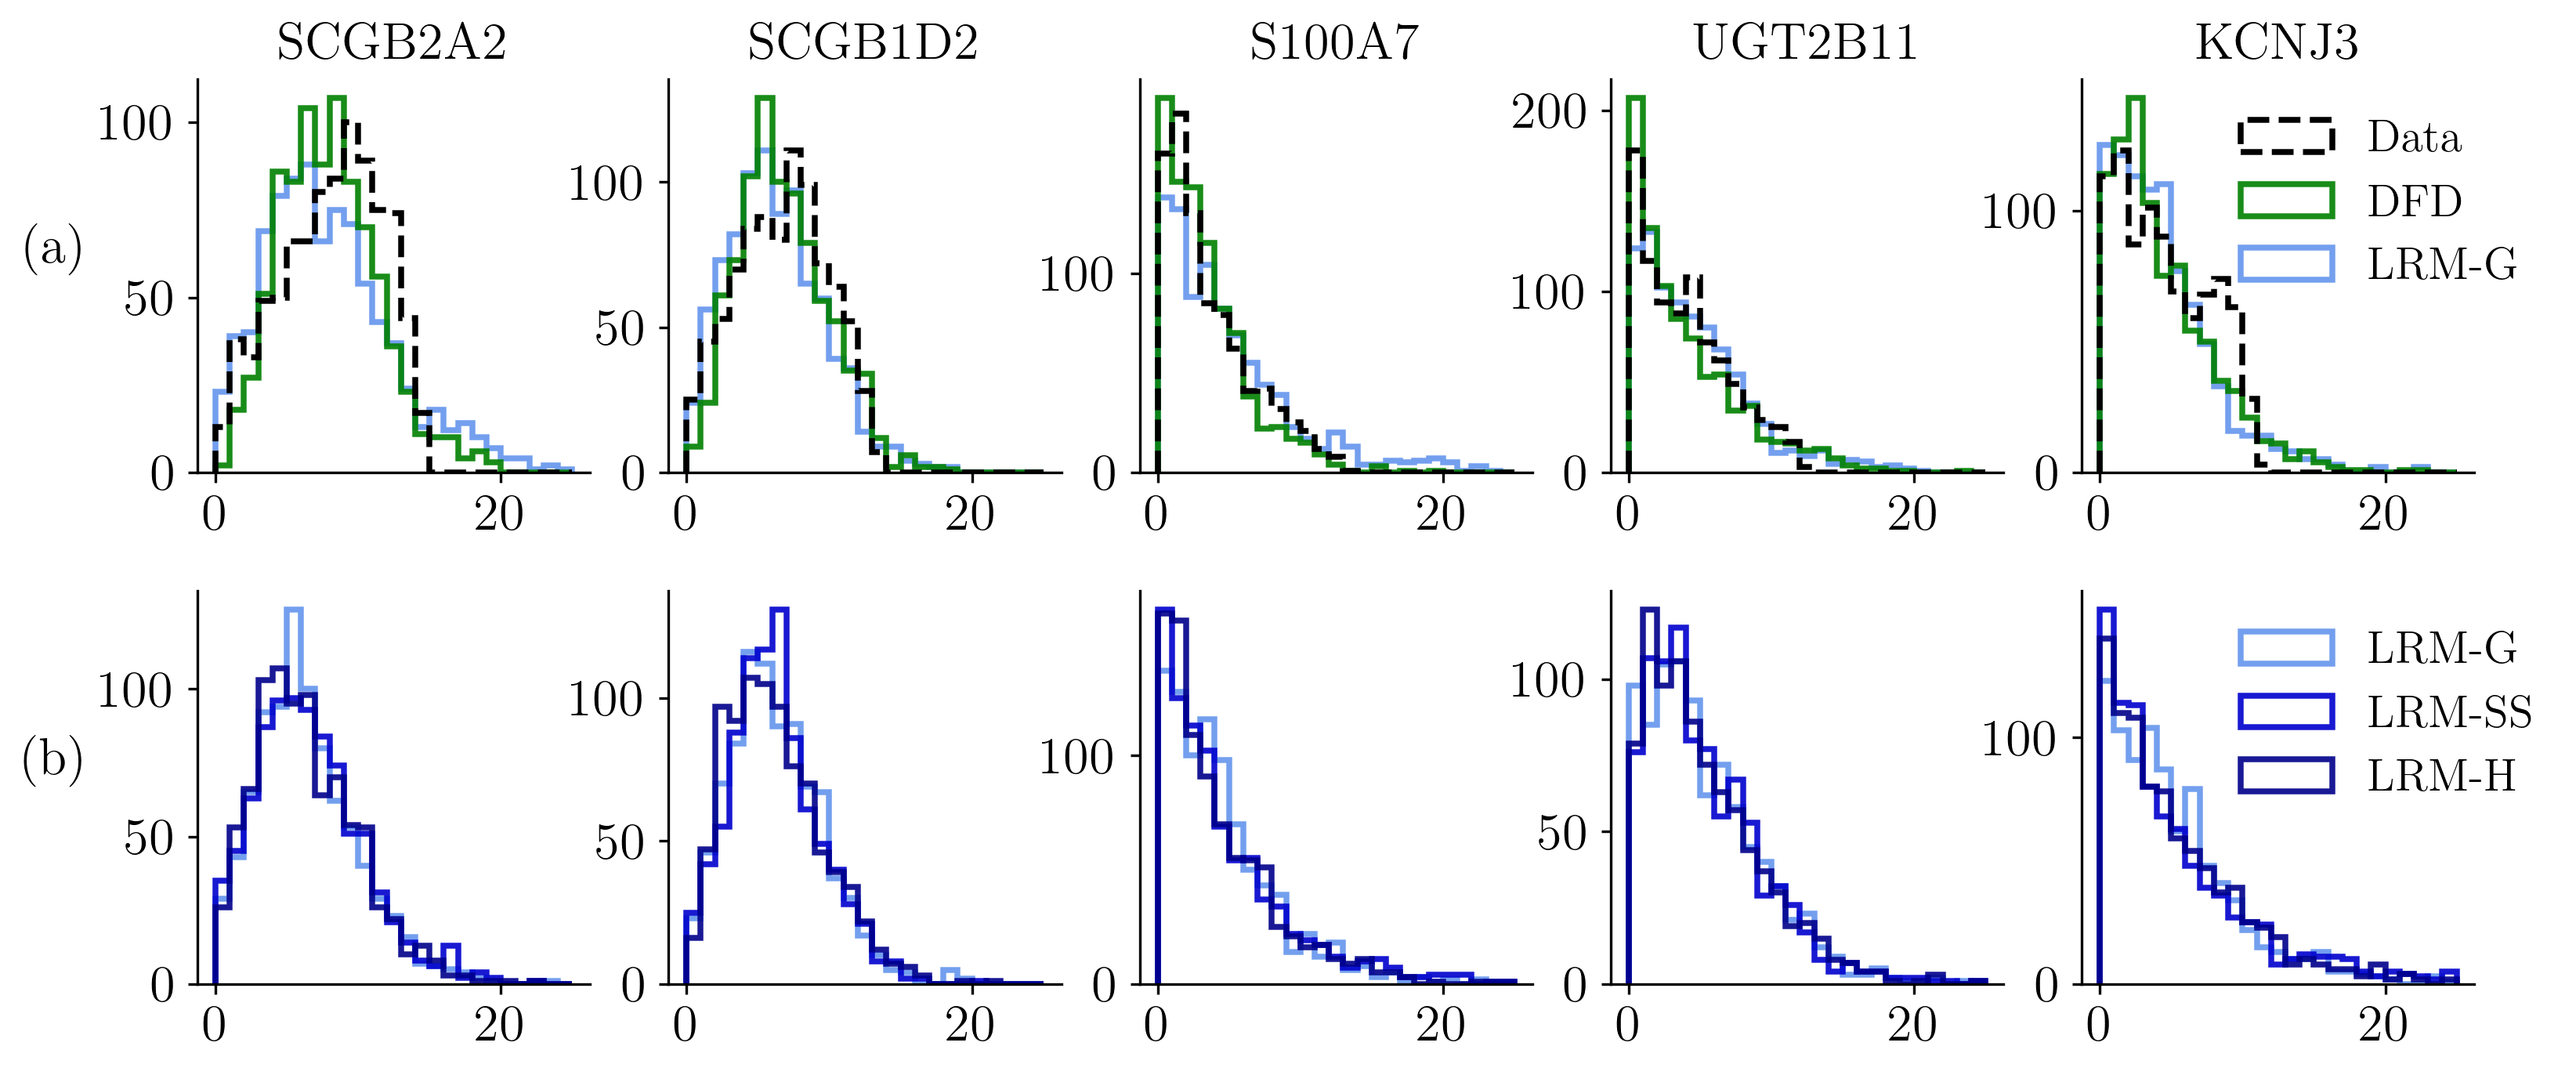

In [7]:
labels_appendix = [lab for lab in flat_labels if lab not in labels_main]
selected_appendix_idx = [label_to_idx[lab] for lab in labels_appendix]

plot(labels_appendix, selected_appendix_idx, figsize=(12.5, 5.), save=True, filename="./results/BRCA-study-all-appendix-text.pdf")